In [ ]:
"""
This code performs data preprocessing, trains a logistic regression model to predict whether a user will purchase an item based on their age and salary, evaluates the model using confusion matrix and classification metrics, and visualizes the results."""


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from mlxtend.plotting import plot_confusion_matrix
from sklearn.metrics import (confusion_matrix, 
                           classification_report, 
                           accuracy_score,
                           precision_score,
                           recall_score)
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:
df = pd.read_csv("Social_Network_Ads.csv")

In [4]:
print("Dataset head:")
print(df.head())

Dataset head:
    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


In [6]:
print("\nDataset shape:")
print(df.shape)


Dataset shape:
(400, 5)


In [7]:
print("\nDataset info:")
print(df.info())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB
None


In [8]:
print("\nDataset statistics:")
print(df.describe())


Dataset statistics:
            User ID         Age  EstimatedSalary   Purchased
count  4.000000e+02  400.000000       400.000000  400.000000
mean   1.569154e+07   37.655000     69742.500000    0.357500
std    7.165832e+04   10.482877     34096.960282    0.479864
min    1.556669e+07   18.000000     15000.000000    0.000000
25%    1.562676e+07   29.750000     43000.000000    0.000000
50%    1.569434e+07   37.000000     70000.000000    0.000000
75%    1.575036e+07   46.000000     88000.000000    1.000000
max    1.581524e+07   60.000000    150000.000000    1.000000


In [9]:
print("\nMissing values:")
print(df.isna().sum())


Missing values:
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


In [10]:
print("\nGender distribution:")
print(df["Gender"].value_counts())


Gender distribution:
Gender
Female    204
Male      196
Name: count, dtype: int64


In [11]:
def gender_encoder(value):
    if value == "Male":
        return 1
    elif value == "Female":
        return 0
    else:
        return -1

In [12]:
df["Gender"] = df["Gender"].apply(gender_encoder)

In [13]:
print("\nPurchased distribution:")
print(df["Purchased"].value_counts())


Purchased distribution:
Purchased
0    257
1    143
Name: count, dtype: int64


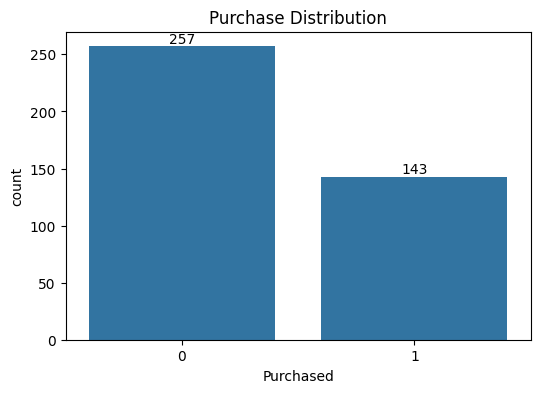

In [14]:
plt.figure(figsize=(6,4))
countplot = sns.countplot(x=df["Purchased"])
for i in countplot.containers:
    countplot.bar_label(i)
plt.title("Purchase Distribution")
plt.show()

In [15]:
X = df[["Age", "EstimatedSalary"]]
y = df["Purchased"]

In [16]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("\nTrain/test shapes:")
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


Train/test shapes:
(320, 2) (80, 2) (320,) (80,)


In [18]:
model = LogisticRegression(n_jobs=-1)
model.fit(X_train, y_train)

LogisticRegression(n_jobs=-1)

In [19]:
y_pred = model.predict(X_test)

In [20]:
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[50  2]
 [ 9 19]]


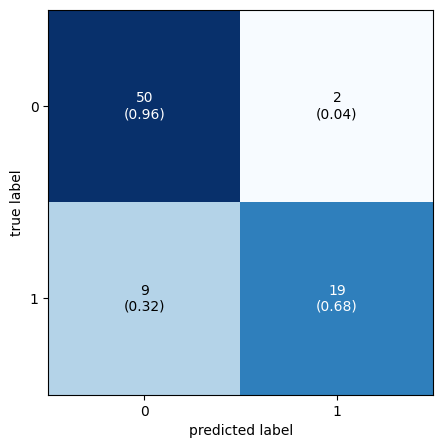

In [21]:
plot_confusion_matrix(conf_mat=cm, figsize=(5,5), show_normed=True)
plt.show()

In [22]:
print(f"\nTN value is {cm[0][0]}")
print(f"FP value is {cm[0][1]}")
print(f"FN value is {cm[1][0]}")
print(f"TP value is {cm[1][1]}")


TN value is 50
FP value is 2
FN value is 9
TP value is 19


In [23]:
print(f"\nAccuracy score is {accuracy_score(y_test, y_pred)}")
print(f"Error rate is {1-accuracy_score(y_test, y_pred)}")
print(f"Precision score is {precision_score(y_test, y_pred)}")
print(f"Recall score is {recall_score(y_test, y_pred)}")


Accuracy score is 0.8625
Error rate is 0.13749999999999996
Precision score is 0.9047619047619048
Recall score is 0.6785714285714286


In [24]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.96      0.90        52
           1       0.90      0.68      0.78        28

    accuracy                           0.86        80
   macro avg       0.88      0.82      0.84        80
weighted avg       0.87      0.86      0.86        80



In [ ]:
"""2.1 Importing Required Libraries
python
Copy
Edit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from mlxtend.plotting import plot_confusion_matrix
from sklearn.metrics import (confusion_matrix, 
                           classification_report, 
                           accuracy_score,
                           precision_score,
                           recall_score)
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
pandas: Used for handling and analyzing the dataset.

numpy: Provides support for numerical operations.

matplotlib.pyplot, seaborn: Used for data visualization.

StandardScaler: Scales the features to standardize them (zero mean, unit variance).

train_test_split: Splits data into training and testing sets.

LogisticRegression: Used to train a logistic regression model.

plot_confusion_matrix: Used to plot the confusion matrix.

confusion_matrix, classification_report, accuracy_score, precision_score, recall_score: Used to evaluate the model's performance.

warnings.filterwarnings('ignore'): Ignores warnings to clean up output.

%matplotlib inline: Ensures that plots are displayed inline in Jupyter Notebooks.

2.2 Loading and Previewing the Dataset


df = pd.read_csv("Social_Network_Ads.csv")
print("Dataset head:")
print(df.head())
Reads the CSV file Social_Network_Ads.csv into a DataFrame df.

Displays the first 5 rows of the dataset to provide an overview.



print("\nDataset shape:")
print(df.shape)
Prints the shape of the dataset (number of rows and columns).



print("\nDataset info:")
print(df.info())
Displays general information about the dataset, such as column names, non-null count, and data types.



print("\nDataset statistics:")
print(df.describe())
Prints summary statistics (count, mean, std, min, max, etc.) for numerical columns.



print("\nMissing values:")
print(df.isna().sum())
Checks for missing values in the dataset and prints the count of missing values for each column.

2.3 Encoding Gender Column


def gender_encoder(value):
    if value == "Male":
        return 1
    elif value == "Female":
        return 0
    else:
        return -1
df["Gender"] = df["Gender"].apply(gender_encoder)
Defines a function gender_encoder() that maps "Male" to 1 and "Female" to 0.

Applies the function to the Gender column to encode gender as numerical values (1 for Male, 0 for Female).

2.4 Displaying Purchase Distribution


print("\nPurchased distribution:")
print(df["Purchased"].value_counts())
Displays the count of users who purchased (1) and did not purchase (0).



plt.figure(figsize=(6,4))
countplot = sns.countplot(x=df["Purchased"])
for i in countplot.containers:
    countplot.bar_label(i)
plt.title("Purchase Distribution")
plt.show()
Creates a bar plot to visualize the distribution of purchases.

The countplot function counts occurrences of each category in the Purchased column and labels the bars.

2.5 Feature Selection and Data Scaling


X = df[["Age", "EstimatedSalary"]]
y = df["Purchased"]
scaler = StandardScaler()
X = scaler.fit_transform(X)
X: Selects features Age and EstimatedSalary.

y: Selects the target variable Purchased.

Standardizes the features (X) using StandardScaler, which scales the data to have a mean of 0 and standard deviation of 1.

2.6 Splitting Data into Training and Testing Sets


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("\nTrain/test shapes:")
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
Splits the data into training and testing sets using train_test_split().

test_size=0.2: 20% of the data will be used for testing.

random_state=42: Ensures reproducibility of the data split.

Prints the shapes of the training and testing datasets.

2.7 Training the Logistic Regression Model


model = LogisticRegression(n_jobs=-1)
model.fit(X_train, y_train)
Creates a logistic regression model and trains it using the training data (X_train and y_train).

2.8 Making Predictions and Model Evaluation


y_pred = model.predict(X_test)
Uses the trained model to predict values (y_pred) on the test data (X_test).



cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
plot_confusion_matrix(conf_mat=cm, figsize=(5,5), show_normed=True)
plt.show()
Computes the confusion matrix (cm) to evaluate the model's performance.

Displays the confusion matrix and plots it using plot_confusion_matrix().



print(f"\nTN value is {cm[0][0]}")
print(f"FP value is {cm[0][1]}")
print(f"FN value is {cm[1][0]}")
print(f"TP value is {cm[1][1]}")
Prints the values from the confusion matrix:

TN (True Negative), FP (False Positive), FN (False Negative), TP (True Positive).

2.9 Performance Metrics


print(f"\nAccuracy score is {accuracy_score(y_test, y_pred)}")
print(f"Error rate is {1-accuracy_score(y_test, y_pred)}")
print(f"Precision score is {precision_score(y_test, y_pred)}")
print(f"Recall score is {recall_score(y_test, y_pred)}")
Prints the accuracy, error rate, precision, and recall of the model:

Accuracy: The proportion of correct predictions.

Error rate: 1 minus the accuracy.

Precision: Proportion of true positives out of all predicted positives.

Recall: Proportion of true positives out of all actual positives.



print("\nClassification Report:")
print(classification_report(y_test, y_pred))
Prints the classification report, which includes precision, recall, F1-score, and support for each class."""